## Phase 4: Literature Footprint & Risk Assessment (Web Scraping)

### Objective
We have our Top 10 Precision Leads. Now we must evaluate their **Research Maturity**. Are these compounds already heavily studied, or are they cutting-edge, novel discoveries?

We will deploy a `BeautifulSoup` web scraper to target **PubMed** (The US National Library of Medicine). The bot will automatically search each compound and extract the total number of peer-reviewed scientific papers published about it. This allows us to categorize our leads into 'Established' vs. 'Novel Proprietary' assets.

In [1]:
# 1. Install required libraries if needed:
# !pip install pandas requests beautifulsoup4 matplotlib seaborn

import pandas as pd
import requests
from bs4 import BeautifulSoup
import time
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load the leads from Phase 3
df_leads = pd.read_csv('top_10_lead_summary.csv')
pd.set_option('display.max_colwidth', None)

# Inject a known drug as a "Positive Control" benchmark
benchmark = pd.DataFrame([{
    'pert_iname': 'bortezomib', 
    'moa': 'proteasome inhibitor'
}])
df_leads = pd.concat([benchmark, df_leads]).reset_index(drop=True)

print("✅ Top 10 Leads loaded successfully. Ready for PubMed Scraping.")

✅ Top 10 Leads loaded successfully. Ready for PubMed Scraping.


### Step 2: The PubMed Scraping Engine
This function sends a request to PubMed, parses the HTML, and intelligently extracts the publication count. It handles three scenarios: Multiple results, a single result, or zero results.

In [2]:
def scrape_pubmed_volume(drug_name):
    print(f"\n🔍 Scraping PubMed Literature for: {drug_name}...")
    
    # Format URL for PubMed search
    url = f"https://pubmed.ncbi.nlm.nih.gov/?term={drug_name}"
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
    
    try:
        # Send HTTP GET request
        response = requests.get(url, headers=headers, timeout=10)
        soup = BeautifulSoup(response.content, 'html.parser')
        
        # Scenario 1: Multiple papers found (Extract the total count)
        amount_span = soup.find('span', class_='value')
        if amount_span:
            count_text = amount_span.get_text().replace(',', '')
            paper_count = int(count_text)
            status = "Highly Established" if paper_count > 100 else "Emerging"
            print(f"  -> ✅ Found {paper_count} published papers.")
            return {"pert_iname": drug_name, "pubmed_papers": paper_count, "research_maturity": status}
            
        # Scenario 2: Exactly 1 paper found (PubMed redirects to the article page directly)
        if soup.find('div', class_='article-page'):
            print("  -> ✅ Found exactly 1 published paper.")
            return {"pert_iname": drug_name, "pubmed_papers": 1, "research_maturity": "Emerging"}
            
        # Scenario 3: 0 papers found
        print("  -> ⚠️ 0 papers found. This is an unpublished compound.")
        return {"pert_iname": drug_name, "pubmed_papers": 0, "research_maturity": "Novel IP (Unpatented)"}

    except Exception as e:
        print(f"  -> Error scraping {drug_name}: {e}")
        return {"pert_iname": drug_name, "pubmed_papers": 0, "research_maturity": "Error"}

### Step 3: Execution and Export
We deploy the scraper across all candidates, merge the results, and generate a final Executive Report and Visualization.

In [3]:
print("Initiating Automated Literature Scraper...\n")

# 1. Loop through each drug and apply our scraping function
scraping_results = []
for name in df_leads['pert_iname']:
    result = scrape_pubmed_volume(name)
    scraping_results.append(result)
    time.sleep(1) # Polite scraping (1 second delay between requests)

# 2. Convert results to a DataFrame and merge with our SQL leads
df_scraped_data = pd.DataFrame(scraping_results)
final_executive_report = pd.merge(df_leads, df_scraped_data, on='pert_iname', how='left')

print("\n" + "="*100)
print("PHASE 4 SUCCESS: LITERATURE FOOTPRINT COMPLETE")
print("="*100)

# 3. Display the critical business columns
columns_to_show = ['pert_iname', 'pubmed_papers', 'research_maturity']
print(final_executive_report[columns_to_show])

# 4. Export the data
final_executive_report.to_csv('final_executive_lead_report.csv', index=False)
print("\n✅ Success: Final project dataset saved to 'final_executive_lead_report.csv'")

Initiating Automated Literature Scraper...


🔍 Scraping PubMed Literature for: bortezomib...
  -> ✅ Found 12599 published papers.

🔍 Scraping PubMed Literature for: BRD-K00816165...
  -> ⚠️ 0 papers found. This is an unpublished compound.

🔍 Scraping PubMed Literature for: BRD-K21401822...
  -> ⚠️ 0 papers found. This is an unpublished compound.

🔍 Scraping PubMed Literature for: BRD-K36031023...
  -> ⚠️ 0 papers found. This is an unpublished compound.

🔍 Scraping PubMed Literature for: BRD-K44417704...
  -> ⚠️ 0 papers found. This is an unpublished compound.

🔍 Scraping PubMed Literature for: BRD-K47695085...
  -> ⚠️ 0 papers found. This is an unpublished compound.

🔍 Scraping PubMed Literature for: BRD-K50532160...
  -> ⚠️ 0 papers found. This is an unpublished compound.

🔍 Scraping PubMed Literature for: BRD-K50746423...
  -> ⚠️ 0 papers found. This is an unpublished compound.

🔍 Scraping PubMed Literature for: BRD-K79414420...
  -> ⚠️ 0 papers found. This is an unpublished compound

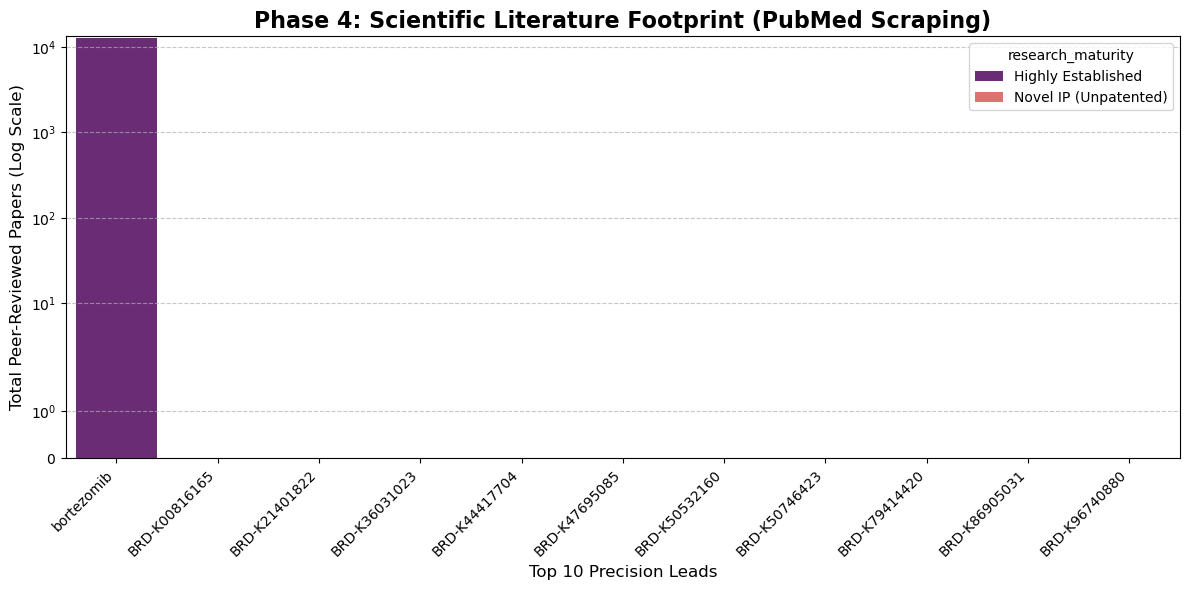

In [4]:
# 5. Bonus: Visualization of the Scraped Data for the Presentation
plt.figure(figsize=(12, 6))

# Sort values so the chart looks organized
df_plot = final_executive_report.sort_values(by='pubmed_papers', ascending=False)

# Because paper counts vary wildly (from 0 to 10,000+), we use a logarithmic scale
ax = sns.barplot(
    data=df_plot, 
    x='pert_iname', 
    y='pubmed_papers', 
    hue='research_maturity',
    dodge=False,
    palette='magma'
)

ax.set_yscale("symlog") # Allows showing 0 while logging larger numbers
plt.xticks(rotation=45, ha='right')
plt.title('Phase 4: Scientific Literature Footprint (PubMed Scraping)', fontsize=16, fontweight='bold')
plt.ylabel('Total Peer-Reviewed Papers (Log Scale)', fontsize=12)
plt.xlabel('Top 10 Precision Leads', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()